## 1) 设定环境并读取基本信息
解析 `dataset_info.json` 以动态获取数据特征（通道数、采样点、类别等），消除硬编码。

In [1]:
import json
import h5py
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
import copy
from torch.utils.data import DataLoader

# 假设自定义的 Dataset 路径已正确配置
from course_project.TEST_DATASET import TrainDataset, TestDataset

DATA_NAME = "BCIC2A" 
DATA_INFO_PATH = f"course_project/{DATA_NAME}/dataset_info.json"
INDEX_PATH_TRAIN = f"course_project/{DATA_NAME}/train.h5"
INDEX_PATH_VAL = f"course_project/{DATA_NAME}/val.h5"
INDEX_PATH_TEST = f"course_project/{DATA_NAME}/test_x_only.h5"

with open(DATA_INFO_PATH, "r", encoding="utf-8") as f:
    info = json.load(f)

num_labels = info["dataset"]["num_labels"]
category_list = info["dataset"]["category_list"]
channels = info["dataset"]["channels"]
target_sampling_rate = info["processing"]["target_sampling_rate"]
window_sec = info["processing"]["window_sec"]

print("=== Dataset Information ===")
print("Number of Labels:", num_labels)
print("Categories:", category_list)
print("Channels (count):", len(channels))
print("Target Sampling Rate (Hz):", target_sampling_rate)
print("Window Size (sec):", window_sec)

# 动态确定输入特征维度
time_points = int(target_sampling_rate * window_sec)
num_channels = len(channels)
num_classes = num_labels

=== Dataset Information ===
Number of Labels: 4
Categories: ['left', 'right', 'foot', 'tongue']
Channels (count): 22
Target Sampling Rate (Hz): 200.0
Window Size (sec): 1.0


## 2) 检查数据形状

In [3]:
print("========== 检查训练集 (Train) ==========")
with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))
    
print("\n========== 检查验证集 (Validation) ==========")
with h5py.File(INDEX_PATH_VAL, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))
    
print("\n========== 检查测试集 (Test - X only) ==========")
with h5py.File(INDEX_PATH_TEST, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)

========== 检查训练集 (Train) ==========
keys: ['X', 'y']
x dtype: float32
x shape: (720, 22, 800)
y dtype: int64
y shape: (720,)
unique: [0 1 2 3]

========== 检查验证集 (Validation) ==========
keys: ['X', 'y']
x dtype: float32
x shape: (360, 22, 800)
y dtype: int64
y shape: (360,)
unique: [0 1 2 3]

========== 检查测试集 (Test - X only) ==========
keys: ['X']
x dtype: float32
x shape: (360, 22, 800)


## 3) 定义模型
这里预留了模型替换的空间。

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EEGConformer(nn.Module):
    """
    EEG-Conformer: Convolutional Transformer for EEG Decoding and Visualization
    结合了 CNN 提取局部特征的优势，以及 Transformer 捕捉全局时序依赖的优势。
    """
    def __init__(self, input_channels, num_classes, time_points=200):
        super(EEGConformer, self).__init__()
        
        # ==========================================
        # 1. 卷积模块 (Patch Embedding)
        # 作用：充当 Tokenizer，提取脑电信号的空时局部特征
        # ==========================================
        # 1.1 时间维度的卷积 (提取特定频段的节律特征)
        # kernel_size=(1, 25) 是一个经验值，大约能覆盖 100ms 左右的信号变化
        self.temporal_conv = nn.Conv2d(1, 40, kernel_size=(1, 25), padding=(0, 12), bias=False)
        self.bn1 = nn.BatchNorm2d(40)
        
        # 1.2 空间维度的深度卷积 (混合通道，提取空间模式)
        self.spatial_conv = nn.Conv2d(40, 40, kernel_size=(input_channels, 1), bias=False)
        self.bn2 = nn.BatchNorm2d(40)
        
        # 1.3 时间维度的平均池化 (降维，构成 Transformer 的 Token)
        self.pool = nn.AvgPool2d((1, 5), stride=(1, 5))
        self.dropout_cnn = nn.Dropout(0.3)

        # ==========================================
        # 动态推导 Transformer 的序列长度和特征维度
        # ==========================================
        with torch.no_grad():
            # 构造一个 dummy input 来测算卷积和池化后的形状
            dummy_x = torch.zeros(1, 1, input_channels, time_points)
            dummy_x = self.temporal_conv(dummy_x)
            dummy_x = self.spatial_conv(dummy_x)
            dummy_x = self.pool(dummy_x)
            # 此时 dummy_x 的形状为 (Batch, Features, 1, Seq_len)
            _, d_model, _, seq_len = dummy_x.shape
            
        self.d_model = d_model  # 每个时间切片的特征维度 (40)
        self.seq_len = seq_len  # 序列的长度

        # ==========================================
        # 2. Transformer 模块
        # ==========================================
        # 分类 Token (类似于 Vision Transformer 中的 CLS token)
        self.cls_token = nn.Parameter(torch.randn(1, 1, self.d_model))
        
        # 绝对位置编码 (+1 是因为加入了 CLS token)
        self.pos_embedding = nn.Parameter(torch.randn(1, self.seq_len + 1, self.d_model))
        
        # Transformer Encoder 层 (原论文通常使用 2-4 层，这里使用轻量级配置避免过拟合)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=4,             # 多头注意力的头数
            dim_feedforward=128, # 前馈网络的维度
            dropout=0.5,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # ==========================================
        # 3. 分类器模块
        # ==========================================
        self.classifier = nn.Sequential(
            nn.Linear(self.d_model, 64),
            nn.ELU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x 输入形状: (Batch, Channels, Time) -> 扩展为 (Batch, 1, Channels, Time)
        x = x.unsqueeze(1)
        
        # --- 局部 CNN 提取 ---
        x = self.temporal_conv(x)
        x = F.elu(self.bn1(x))
        x = self.spatial_conv(x)
        x = F.elu(self.bn2(x))
        x = self.pool(x)
        x = self.dropout_cnn(x)
        
        # --- 形状转换以适配 Transformer ---
        # (B, 40, 1, Seq) -> (B, 40, Seq) -> (B, Seq, 40)
        x = x.squeeze(2).permute(0, 2, 1)
        
        # --- 拼接 CLS Token ---
        B = x.shape[0]
        # (1, 1, 40) 扩展为 (B, 1, 40)
        cls_tokens = self.cls_token.expand(B, -1, -1) 
        # 在序列维度上拼接: (B, Seq+1, 40)
        x = torch.cat((cls_tokens, x), dim=1)
        
        # --- 注入位置信息并进行自注意力计算 ---
        x = x + self.pos_embedding
        x = self.transformer(x)
        
        # --- 分类 ---
        # 提取 CLS Token 的输出状态进行分类 (索引为 0 的位置)
        cls_output = x[:, 0, :]
        logits = self.classifier(cls_output)
        
        return logits

## 4) 配置数据加载器、设备与优化器
添加了设备自适应检测（CUDA GPU / Apple MPS / CPU），并优化了超参数区域。

In [15]:
# -------------------------
# 超参数设定
# -------------------------
BATCH_SIZE = 64
EPOCHS = 200          # 增加总 Epoch 数，依靠早停来控制结束
LR = 5e-4
PATIENCE = 20        # 早停的耐心值（验证集持续多少轮不上升则停止）

# -------------------------
# 设定计算设备 (GPU / MPS / CPU)
# -------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# -------------------------
# 准备 DataLoader
# -------------------------
train_ds = TrainDataset(INDEX_PATH_TRAIN)
val_ds = TrainDataset(INDEX_PATH_VAL)   
test_ds = TestDataset(INDEX_PATH_TEST)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# 新增： 动态获取真实的 time_points，彻底避免维度不匹配
sample_x, _ = train_ds[0]  
real_time_points = sample_x.shape[1] 

if real_time_points != time_points:
    print(f"检测到真实的采样点长度 (Time Points): {real_time_points}，与预设值 {time_points} 不一致")

# -------------------------
# 实例化模型、损失函数、优化器
# -------------------------
model = EEGConformer(
    input_channels=num_channels,
    time_points=real_time_points,
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4) # 增加轻度 L2 正则化缓解过拟合

Using device: cpu
检测到真实的采样点长度 (Time Points): 800，与预设值 200 不一致


## 5) 模型训练与验证
实现了 **Early Stopping** 和 **Best Model 保存机制**。避免模型训练到最后已经严重过拟合。

In [16]:
# 用于记录曲线的数组
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

best_val_acc = 0.0
best_model_weights = None
epochs_no_improve = 0
has_saved_model = False
best_model_path = None 

os.makedirs("model_checkpoints", exist_ok=True)

for epoch in range(EPOCHS):
    # ===== Train =====
    model.train()
    train_loss_sum = 0.0
    train_correct = 0  
    train_num = 0

    for data, label in train_loader:
        data, label = data.to(device), label.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()

        batch_size = label.size(0)
        train_loss_sum += loss.item() * batch_size
        train_num += batch_size

        train_pred = torch.argmax(output, dim=1)
        train_correct += (train_pred == label).sum().item()

    epoch_train_loss = train_loss_sum / train_num
    epoch_train_acc = train_correct / train_num  
    
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)     

    # ===== Validation =====
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_num = 0

    with torch.no_grad():
        for val_data, val_label in val_loader:
            val_data, val_label = val_data.to(device), val_label.to(device)
            
            val_output = model(val_data)
            val_loss = criterion(val_output, val_label)

            batch_size = val_label.size(0)
            val_loss_sum += val_loss.item() * batch_size
            val_num += batch_size

            val_pred = torch.argmax(val_output, dim=1)
            val_correct += (val_pred == val_label).sum().item()

    epoch_val_loss = val_loss_sum / val_num
    epoch_val_acc = val_correct / val_num

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # 打印每轮训练结果
    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.2%} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.2%}"
    )

    # ===== 早停与最佳模型保存逻辑 =====
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        epochs_no_improve = 0  # 只要准确率刷新就重置耐心值
        
        # 从第 10 个 epoch 开始，并且超越了历史最佳才实际保存模型
        if epoch + 1 >= 10:
            best_model_weights = copy.deepcopy(model.state_dict())
            # 为文件加上 Val Accuracy 的值作为后缀
            current_model_path = f"model_checkpoints/{DATA_NAME}_best_model_acc{best_val_acc * 100:.2f}.pth"
  
            # 先将删除旧权重，再更新模型路径并保存
            if best_model_path and os.path.exists(best_model_path):
                os.remove(best_model_path)
            best_model_path = current_model_path
            torch.save(best_model_weights, best_model_path)
            has_saved_model = True
            print(f" ---> 出现更高的验证集准确率 ({best_val_acc:.2%})，已更新模型。")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nTriggered Early Stopping at Epoch {epoch+1}!")
            break
            
    if epoch + 1 == 10:
        print(f" ---> 前 10 个 Epoch 结束，目前的最佳验证集准确率为 {best_val_acc:.2%}")

print("\n" + "-" * 40)
print(f"Final Best Val Accuracy: {best_val_acc:.2%}")

# 最终的结果打印判定
if has_saved_model:
    print(f"训练成功结束！最佳模型已保存至: {best_model_path}")
else:
    print("\n【提醒】训练结束但未保存模型！因为在第 10 个 Epoch 之后，准确率没有超越过前期，请调整代码。")

Epoch [01/200] | Train Loss: 1.4233 | Train Acc: 25.56% | Val Loss: 1.3862 | Val Acc: 25.00%
Epoch [02/200] | Train Loss: 1.4190 | Train Acc: 23.06% | Val Loss: 1.3868 | Val Acc: 25.00%
Epoch [03/200] | Train Loss: 1.4129 | Train Acc: 24.58% | Val Loss: 1.3862 | Val Acc: 27.78%
Epoch [04/200] | Train Loss: 1.4109 | Train Acc: 26.11% | Val Loss: 1.3851 | Val Acc: 27.22%
Epoch [05/200] | Train Loss: 1.4024 | Train Acc: 25.83% | Val Loss: 1.3840 | Val Acc: 27.78%
Epoch [06/200] | Train Loss: 1.3939 | Train Acc: 26.25% | Val Loss: 1.3823 | Val Acc: 24.44%
Epoch [07/200] | Train Loss: 1.4023 | Train Acc: 25.97% | Val Loss: 1.3733 | Val Acc: 30.83%
Epoch [08/200] | Train Loss: 1.3997 | Train Acc: 28.47% | Val Loss: 1.3749 | Val Acc: 26.11%
Epoch [09/200] | Train Loss: 1.4116 | Train Acc: 24.44% | Val Loss: 1.3636 | Val Acc: 31.39%
Epoch [10/200] | Train Loss: 1.3981 | Train Acc: 26.53% | Val Loss: 1.3633 | Val Acc: 30.00%
 ---> 前 10 个 Epoch 结束，目前的最佳验证集准确率为 31.39%
Epoch [11/200] | Train Loss:

## 6) 训练过程可视化

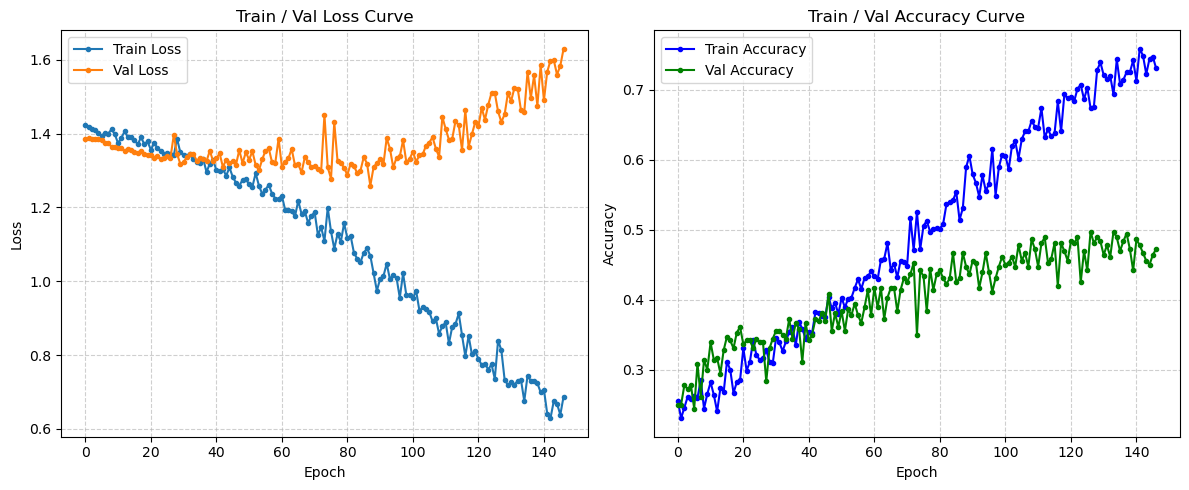

In [17]:
plt.figure(figsize=(12, 5))

# 绘制 Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", marker='o', markersize=3)
plt.plot(val_losses, label="Val Loss", marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Val Loss Curve")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 绘制 Accuracy 曲线
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy", marker='o', markersize=3, color='blue')
plt.plot(val_accuracies, label="Val Accuracy", marker='o', markersize=3, color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train / Val Accuracy Curve") 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

## 7) 测试集推理与结果生成
执行测试推理前，将回载上面跑出来的“最佳验证集权重”，以此来产出最终提交的结果。

In [ ]:
# -------------------------
# 加载最佳模型权重
# -------------------------
print(f"Loading best model from {best_model_path} for testing...")
model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
model.eval()

output_path = f'course_project/{DATA_NAME}/{DATA_NAME}.txt'
all_test_labels = []

with torch.no_grad():
    for test_data in test_loader:  # test_loader 已经是 shuffle=False
        test_data = test_data.to(device)
        test_output = model(test_data)
        test_pred = torch.argmax(test_output, dim=1)
        all_test_labels.extend(test_pred.cpu().tolist())

# 保存 test 预测标签（每行一个数字）
with open(output_path, "w", encoding="utf-8") as f:
    for label in all_test_labels:
        f.write(f"{int(label)}\n")

print(f"Saved {len(all_test_labels)} labels to: {output_path}")